In [1]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9907407407407407

In [7]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# -------------------------------
# 1. IRIS dataset classification
# -------------------------------

# Load dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM with linear kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

print("IRIS Dataset - Linear Kernel")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))

# Train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

print("\nIRIS Dataset - RBF Kernel")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))


IRIS Dataset - Linear Kernel
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

IRIS Dataset - RBF Kernel
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]



Letter Recognition Dataset - RBF Kernel
Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0  

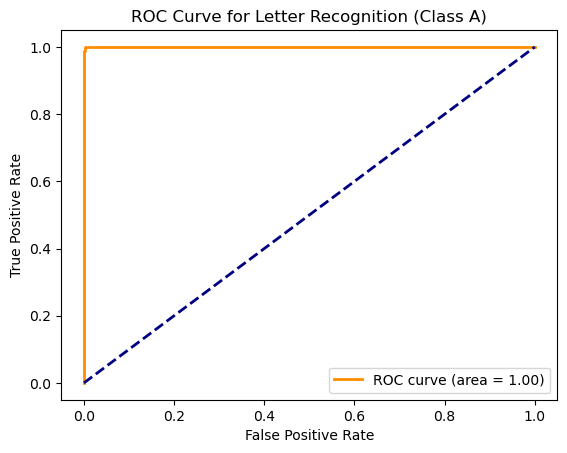

In [14]:
# -------------------------------
# 2. LETTER RECOGNITION dataset classification
# -------------------------------

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize

# Load dataset
letters = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\letter-recognition.data", header=None)
X_letters = letters.iloc[:, 1:].values
y_letters = letters.iloc[:, 0].values

# Encode labels to integers
le = LabelEncoder()
y_letters = le.fit_transform(y_letters)

# Split into train/test (80/20)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_letters, y_letters, test_size=0.2, random_state=42
)

# Train SVM (RBF kernel works well for this dataset)
svm_letters = SVC(kernel='rbf', probability=True, random_state=42)
svm_letters.fit(X_train_l, y_train_l)
y_pred_l = svm_letters.predict(X_test_l)

# Accuracy and Confusion Matrix
print("\nLetter Recognition Dataset - RBF Kernel")
print("Accuracy:", accuracy_score(y_test_l, y_pred_l))
print("Confusion Matrix:\n", confusion_matrix(y_test_l, y_pred_l))

# ROC Curve and AUC
y_score = svm_letters.predict_proba(X_test_l)
y_test_bin = label_binarize(y_test_l, classes=np.arange(len(le.classes_)))

fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for one class (example: class 'A' which is index 0 after encoding)
plt.figure()
plt.plot(fpr[0], tpr[0], color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc[0])
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Letter Recognition (Class A)')
plt.legend(loc="lower right")
plt.show()